# Task 4.2 — Predict HAI Magnitude for H3N2 A/Massachusetts/18/2022 (D28)

**4.2 predict magnitude of antibody response - H3N2 A/Massachusetts/18/2022 (D28)**
* Training Data: Demographics + Day 0 + Day 7 innate
* Assay: HAI / Measure: Single strain titer / Metric: Spearman correlation
* Full description: HAI titer for H3N2 A/Massachusetts/18/2022 at Day 28

---

## Design notes

**Proxy target:** The target strain (H3N2 A/Massachusetts/18/2022) is absent from the training data.
We approximate it by averaging the Day 28 HAI titers of all other H3N2 strains present in the dataset.
All HAI columns are then dropped to prevent leakage.

**Spearman correlation:** ranks predictions and truth; rewards monotonic agreement regardless of scale.
Robust to outliers. Score: 1.0 = perfect, 0.0 = no signal, -1.0 = reversed.

**5-fold cross-validation:** each participant's prediction is made by a model that never saw them during training.

In [1]:
TARGET_COL = 'H3N2_proxy_d28'  # proxy: target strain absent from training data
AUTO_ML_MAX_RUNTIME_SECONDS = 600

In [2]:
PARQUET_PATH = '../merged_data/combined.parquet'
CHALLENGE_DATA_PATH = '../cleaned_data'
SUBMISSION_PATH = '../automl_submission'

In [3]:
import io
import os
import warnings
from contextlib import redirect_stderr, redirect_stdout

import h2o
import numpy as np
import pandas as pd
from h2o.automl import H2OAutoML
from scipy.stats import spearmanr

In [4]:
challenge_participants = pd.read_csv(CHALLENGE_DATA_PATH + '/challenge_participants_cleaned.csv')
challenge_hai = pd.read_csv(CHALLENGE_DATA_PATH + '/challenge_hai_cleaned.csv')
challenge_data = challenge_hai.merge(challenge_participants, on='participant_id', how='inner')
print(f'Challenge shape: {challenge_data.shape}')

Challenge shape: (40, 23)


### Preprocessing — proxy target\n\nThe target strain is absent from the training set. We create a proxy by averaging all H3N2 Day 28 HAI titers.\nRows are filtered to those with a valid proxy target, then all-null columns are removed on the filtered subset.\nThe `_d28`/`_d365` columns are excluded from features at training time to prevent leakage.

In [5]:
df = pd.read_parquet(PARQUET_PATH)
print(f'Raw shape: {df.shape}')

Raw shape: (3757, 110063)


In [6]:
# Create proxy target: row-wise average of all H3N2 d28 HAI strains
h3n2_d28_cols = [c for c in df.columns if c.startswith('HAI_') and 'H3N2' in c and c.endswith('_d28')]
df[TARGET_COL] = df[h3n2_d28_cols].mean(axis=1)
print(f'Proxy target averaged from {len(h3n2_d28_cols)} H3N2 d28 strains')

Proxy target averaged from 25 H3N2 d28 strains


In [7]:
# Filter to rows with a valid proxy target first
df = df[df[TARGET_COL].notna()].reset_index(drop=True)
print(f'Rows with valid proxy target: {len(df)}')

# Drop all-null columns on the filtered subset
all_null_cols = df.columns[df.isna().all()].tolist()
df = df.drop(columns=all_null_cols)
print(f'Dropped {len(all_null_cols)} all-null columns → {df.shape[1]} remaining')

# Drop columns with 85%+ missing values
before = df.shape[1]
df = df.loc[:, df.notna().mean() >= 0.15]
print(f'Dropped {before - df.shape[1]} columns with ≥85% missing → {df.shape[1]} remaining')

Rows with valid proxy target: 3568
Dropped 26510 all-null columns → 83554 remaining
Dropped 83478 columns with ≥85% missing → 76 remaining


In [8]:
print(f'Shape: {df.shape}')
print(f'Target stats:\n{df[TARGET_COL].describe()}')
print(f'\ndtype counts:\n{df.dtypes.value_counts()}')
print(f'\nMissing per column (top 10):\n{df.isna().sum().sort_values(ascending=False).head(10)}')

Shape: (3568, 76)
Target stats:
count    3568.000000
mean        5.860525
std         2.024357
min         0.000000
25%         4.321928
50%         5.946928
75%         7.321928
max        14.321928
Name: H3N2_proxy_d28, dtype: float64

dtype counts:
float64    71
object      5
Name: count, dtype: int64

Missing per column (top 10):
HAI_Anc B/Lee/1940_d0                            3028
HAI_Anc B/Lee/1940_d28                           3028
HAI_Yam B/Wisconsin/1/2010_d28                   2888
HAI_Yam B/Wisconsin/1/2010_d0                    2888
HAI_H3N2 A/Uruguay/716/2007_d28                  2885
HAI_H3N2 A/Uruguay/716/2007_d0                   2885
HAI_H3N2 A/Hong Kong/2671/2019_d365              2833
HAI_H1N1 A/Guangdong-Maonan/SWL1536/2019_d365    2833
HAI_H3N2 A/South Australia/34/2019_d365          2833
HAI_H3N2 A/Kansas/14/2017_d365                   2833
dtype: int64


---
## AutoML Setup

In [9]:
warnings.filterwarnings('ignore', category=UserWarning, module='h2o')
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
; Java HotSpot(TM) 64-Bit Server VM (build 17.0.12+8-LTS-286, mixed mode, sharing)
  Starting server from C:\Users\arvin\AppData\Local\Programs\Python\Python313\Lib\site-packages\h2o\backend\bin\h2o.jar
  Ice root: C:\Users\arvin\AppData\Local\Temp\tmppnp_s6zq
  JVM stdout: C:\Users\arvin\AppData\Local\Temp\tmppnp_s6zq\h2o_arvin_started_from_python.out
  JVM stderr: C:\Users\arvin\AppData\Local\Temp\tmppnp_s6zq\h2o_arvin_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,01 secs
H2O_cluster_timezone:,America/Los_Angeles
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,1 month and 26 days
H2O_cluster_name:,H2O_from_python_arvin_qz8erg
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.920 Gb
H2O_cluster_total_cores:,16
H2O_cluster_allowed_cores:,16
H2O_cluster_status:,"locked, healthy"


In [10]:
print(f'Converting to H2O: {df.shape[0]} rows × {df.shape[1]} columns')
data = h2o.H2OFrame(df)
print(f'H2OFrame shape: {data.shape}')

Converting to H2O: 3568 rows × 76 columns
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
H2OFrame shape: (3568, 76)


---
## AutoML Training

In [11]:
# Features: everything available at d0/d7 — exclude all d28/d365 targets and participant_id
x = [c for c in data.columns
     if not c.endswith('_d28') and not c.endswith('_d365')
     and c != 'participant_id']
y = TARGET_COL

train = data[data[y].isna() == 0]
print(f'Training samples: {train.nrows}  |  Features: {len(x)}')

aml = H2OAutoML(max_models=10, seed=1, nfolds=5,
                keep_cross_validation_predictions=True,
                max_runtime_secs=AUTO_ML_MAX_RUNTIME_SECONDS)

_buf = io.StringIO()
with redirect_stdout(_buf), redirect_stderr(_buf):
    aml.train(x=x, y=y, training_frame=train)
print('Training complete.')

Training samples: 3568  |  Features: 34
Training complete.


In [12]:
lb = aml.leaderboard
print(lb.head(rows=lb.nrows))

model_id                                                    rmse      mse       mae     rmsle    mean_residual_deviance
StackedEnsemble_AllModels_1_AutoML_1_20260508_104853     1.20522  1.45257  0.888219  0.19832                    1.45257
StackedEnsemble_BestOfFamily_1_AutoML_1_20260508_104853  1.21393  1.47362  0.894107  0.199695                   1.47362
GBM_4_AutoML_1_20260508_104853                           1.21902  1.48602  0.897724  0.199755                   1.48602
GBM_3_AutoML_1_20260508_104853                           1.21993  1.48823  0.902404  0.199682                   1.48823
GBM_2_AutoML_1_20260508_104853                           1.22062  1.48992  0.894347  0.200179                   1.48992
GBM_5_AutoML_1_20260508_104853                           1.22239  1.49424  0.899623  0.200991                   1.49424
GBM_1_AutoML_1_20260508_104853                           1.22535  1.50148  0.914036  0.201352                   1.50148
GBM_grid_1_AutoML_1_20260508_104853_mode

In [13]:
# Stacked Ensembles don't store CV predictions — fall back to best base model if needed
model = aml.leader
if model.cross_validation_holdout_predictions() is None:
    for m_id in aml.leaderboard['model_id'].as_data_frame()['model_id']:
        m = h2o.get_model(m_id)
        if m.cross_validation_holdout_predictions() is not None:
            model = m
            break

cv_preds = model.cross_validation_holdout_predictions().as_data_frame()['predict']
actuals = train[y].as_data_frame()[y]
rho, pval = spearmanr(actuals, cv_preds)
print(f'Task 4.2 — Spearman (5-fold CV): {rho:.3f}  (p={pval:.4f})')
print(f'Model used for eval: {model.model_id}')

Task 4.2 — Spearman (5-fold CV): 0.793  (p=0.0000)
Model used for eval: GBM_4_AutoML_1_20260508_104853


c:\Users\arvin\AppData\Local\Programs\Python\Python313\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
c:\Users\arvin\AppData\Local\Programs\Python\Python313\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
c:\Users\arvin\AppData\Local\Programs\Python\Python313\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dat

Leader model: StackedEnsemble_AllModels_1_AutoML_1_20260508_104853
Varimp model: GBM_4_AutoML_1_20260508_104853


,variable,relative_importance,scaled_importance,percentage
0,HAI_Yam B/Florida/4/2006_d0,7291.458008,1.000000,0.128406
1,HAI_H3N2 A/Singapore/INFIMH-160019/2016_d0,7021.155273,0.962929,0.123646
2,PART_geolocation,6007.244141,0.823874,0.105791
3,HAI_H3N2 A/Perth/16/2009_d0,5966.722168,0.818317,0.105077
4,HAI_H3N2 A/South Australia/34/2019_d0,3926.152100,0.538459,0.069142
5,HAI_H3N2 A/Uruguay/716/2007_d0,3183.801025,0.436648,0.056068
6,HAI_H1N1 A/Brisbane/59/2007_d0,2723.957520,0.373582,0.047970
7,PART_age,2589.120605,0.355090,0.045596
8,HAI_H3N2 A/Victoria/361/2011_d0,2318.618652,0.317991,0.040832
9,HAI_Vic B/Brisbane/60/2008_d0,2052.990234,0.281561,0.036154


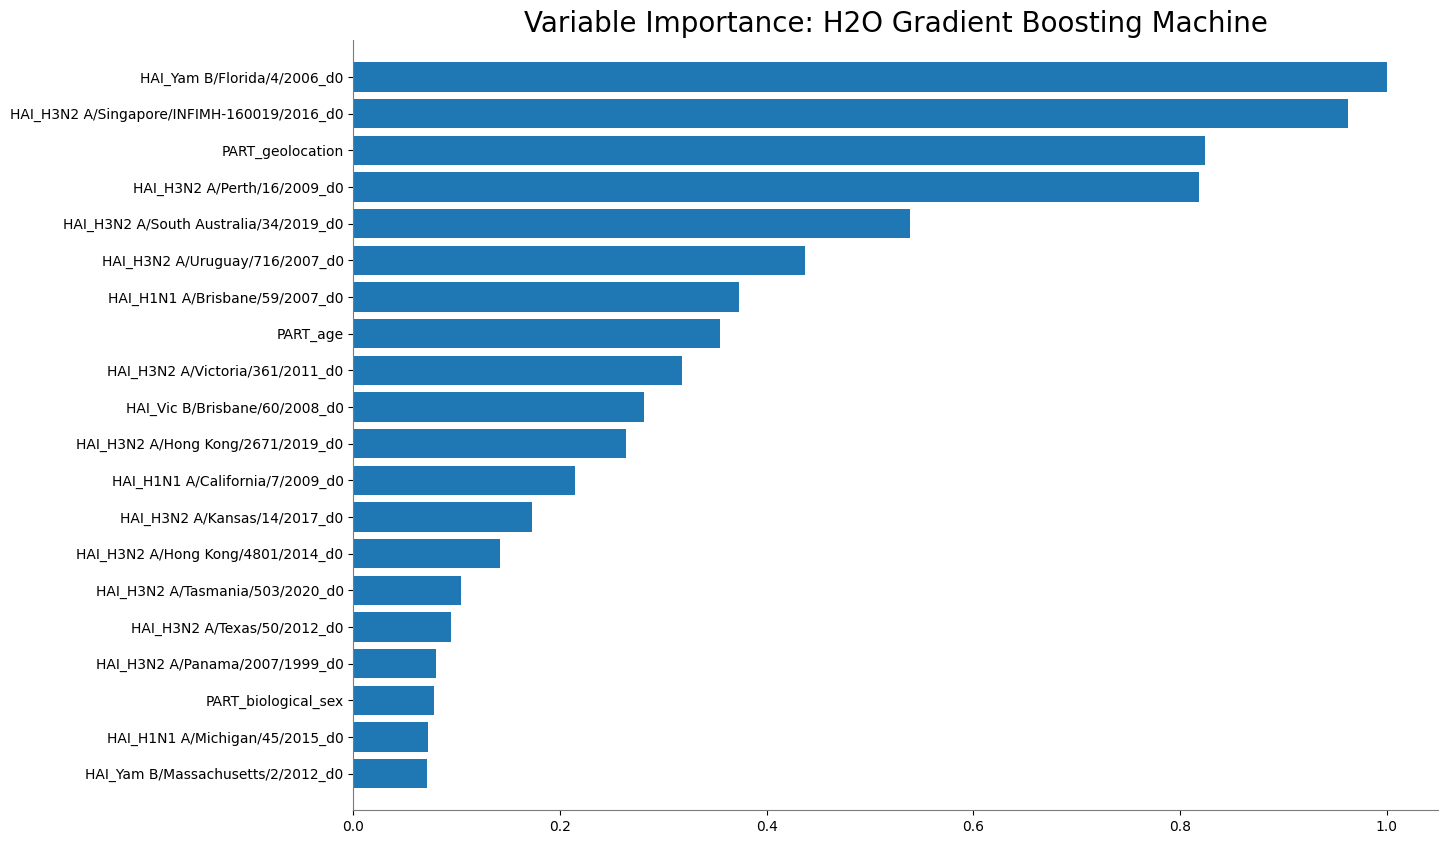

<Figure size 640x480 with 0 Axes>

In [14]:
print(f'Leader model: {aml.leader.model_id}')
print(f'Varimp model: {model.model_id}')
varimp = model.varimp(use_pandas=True)
display(varimp.head(20))
model.varimp_plot(num_of_features=20)

In [ ]:
challenge_hf = h2o.H2OFrame(challenge_data)

# Align column types with training frame to avoid type mismatch errors
for col in challenge_hf.columns:
    if col in data.columns:
        train_type = data[col].types[col]
        test_type = challenge_hf[col].types[col]
        if train_type != test_type:
            if train_type == 'enum':
                challenge_hf[col] = challenge_hf[col].ascharacter().asfactor()
            else:
                challenge_hf[col] = challenge_hf[col].asnumeric()

y_pred = aml.leader.predict(challenge_hf).as_data_frame()['predict']

os.makedirs(SUBMISSION_PATH, exist_ok=True)
results = pd.DataFrame({
    'Participant_ID': challenge_data['participant_id'].values,
    'Task_4.2': np.exp2(y_pred),
})
results.to_csv(f'{SUBMISSION_PATH}/task_4_2.csv', index=False)
results

In [ ]:
h2o.cluster().shutdown()

---
## Conclusion

- **Leader model:** (fill after run)
- **CV Spearman:** (fill after run)

**Target:** Proxy HAI titer for H3N2 A/Massachusetts/18/2022 at D28 (averaged from all available H3N2 d28 strains).
The target strain is absent from the training data; this proxy is our best approximation.

Submission saved to `automl_submission/task_4_2.csv` (raw titer scale via `np.exp2`).